In [1]:
import numpy as np
import os.path as osp
import uproot
import vector

import matplotlib
import matplotlib.pyplot as plt

In [2]:
SAVE_DATA = True
DATA_DIR = './data'

source_path = osp.join(DATA_DIR, "SMEFT_SM_combined_tuple")
target_path = osp.join(DATA_DIR, "SMEFT_EFT_combined_tuple")

## Load the data using Uproot

In [3]:
WEIGHT_NAME = "mcEventWeight"

data_arrays = []
for path in [source_path, target_path]:
    tree = uproot.open(path+".root")["Events"]
    keys = sorted(tree.keys())
    keys.remove(WEIGHT_NAME)
    
    arr = tree.arrays(library='np')
    arr = np.concatenate([arr[key] for key in keys], axis=1)
    arr = np.concatenate([arr, tree.arrays(WEIGHT_NAME, library='np')[WEIGHT_NAME]], axis=1)
    
    # ADD ANY CUTS
    njets_mask = arr[:, keys.index("Njets")] >= 1
    CUTS = njets_mask
    arr = arr[CUTS]

    # REMOVE ANY FEATURES NOT INCLUDED IN TRAINING OR FOR LATER FILTERING
    names = ["Njets"]
    for name in names:
        arr = np.delete(arr, keys.index(name), axis=1)
        keys.remove(name)
    data_arrays.append(arr)

source_array, target_array = data_arrays

In [4]:
s_shape = source_array.shape
t_shape = target_array.shape

print(f"Source: {s_shape[0]:,} events x {s_shape[1]:,} columns")
print(f"Target: {t_shape[0]:,} events x {t_shape[1]:,} columns")
print()

print("Feature columns (column index -> name):")
for i, name in enumerate(keys):
    print(f"{i:2d} -> {name}")
weight_idx = s_shape[1] - 1
print(f"{weight_idx:2d} -> {WEIGHT_NAME}  (appended as last column)")

if s_shape[1] != len(keys) + 1 or t_shape[1] != len(keys) + 1:
    print("\nWarning: number of columns does not match len(keys)+1")

Source: 1,332,522 events x 21 columns
Target: 1,244,182 events x 21 columns

Feature columns (column index -> name):
 0 -> Jet_Eta
 1 -> Jet_Mass
 2 -> Jet_Phi
 3 -> Jet_Pt
 4 -> Muon_Eta0
 5 -> Muon_Eta1
 6 -> Muon_Eta2
 7 -> Muon_Eta3
 8 -> Muon_Mass0
 9 -> Muon_Mass1
10 -> Muon_Mass2
11 -> Muon_Mass3
12 -> Muon_Phi0
13 -> Muon_Phi1
14 -> Muon_Phi2
15 -> Muon_Phi3
16 -> Muon_Pt0
17 -> Muon_Pt1
18 -> Muon_Pt2
19 -> Muon_Pt3
20 -> mcEventWeight  (appended as last column)


## Create the Higgs 4 vector arrays

In [5]:
ZEROS = np.zeros_like(source_array[:, 0])
MUON_PT_IX = keys.index('Muon_Pt0')
MUON_ETA_IX = keys.index('Muon_Eta0')
MUON_PHI_IX = keys.index('Muon_Phi0')
MUON_M_IX = keys.index('Muon_Mass0')

source_HH_4vec = vector.array({"pt":ZEROS,"eta":ZEROS,"phi":ZEROS,"M":ZEROS})
for i in range(4):
    source_HH_4vec += vector.array({
        "pt": source_array[:, MUON_PT_IX+i],
        "eta": source_array[:, MUON_ETA_IX+i],
        "phi": source_array[:, MUON_PHI_IX+i],
        "M": source_array[:, MUON_M_IX+i]
    })

ZEROS = np.zeros_like(target_array[:, 0])
target_HH_4vec = vector.array({"pt":ZEROS,"eta":ZEROS,"phi":ZEROS,"M":ZEROS})
for i in range(4):
    target_HH_4vec += vector.array({
        "pt": target_array[:, MUON_PT_IX+i],
        "eta": target_array[:, MUON_ETA_IX+i],
        "phi": target_array[:, MUON_PHI_IX+i],
        "M": target_array[:, MUON_M_IX+i]
    })

## Look at some plots

Text(0.5, 1.0, 'Distribution of $m_{HH}$ for Data')

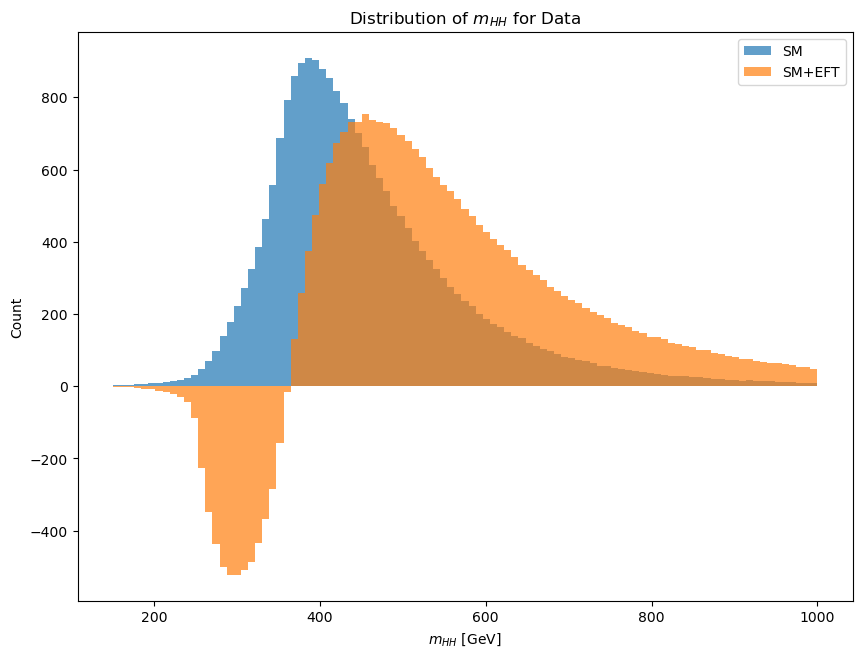

In [6]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = target_array[:,-1] < 0
pos_mask = ~neg_mask

bins = np.linspace(150, 1000, 100)
ax.hist(source_HH_4vec.M, weights=source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_HH_4vec.M, weights=target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT");
ax.set_xlabel(r"$m_{HH}$ [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of $m_{HH}$ for Data")

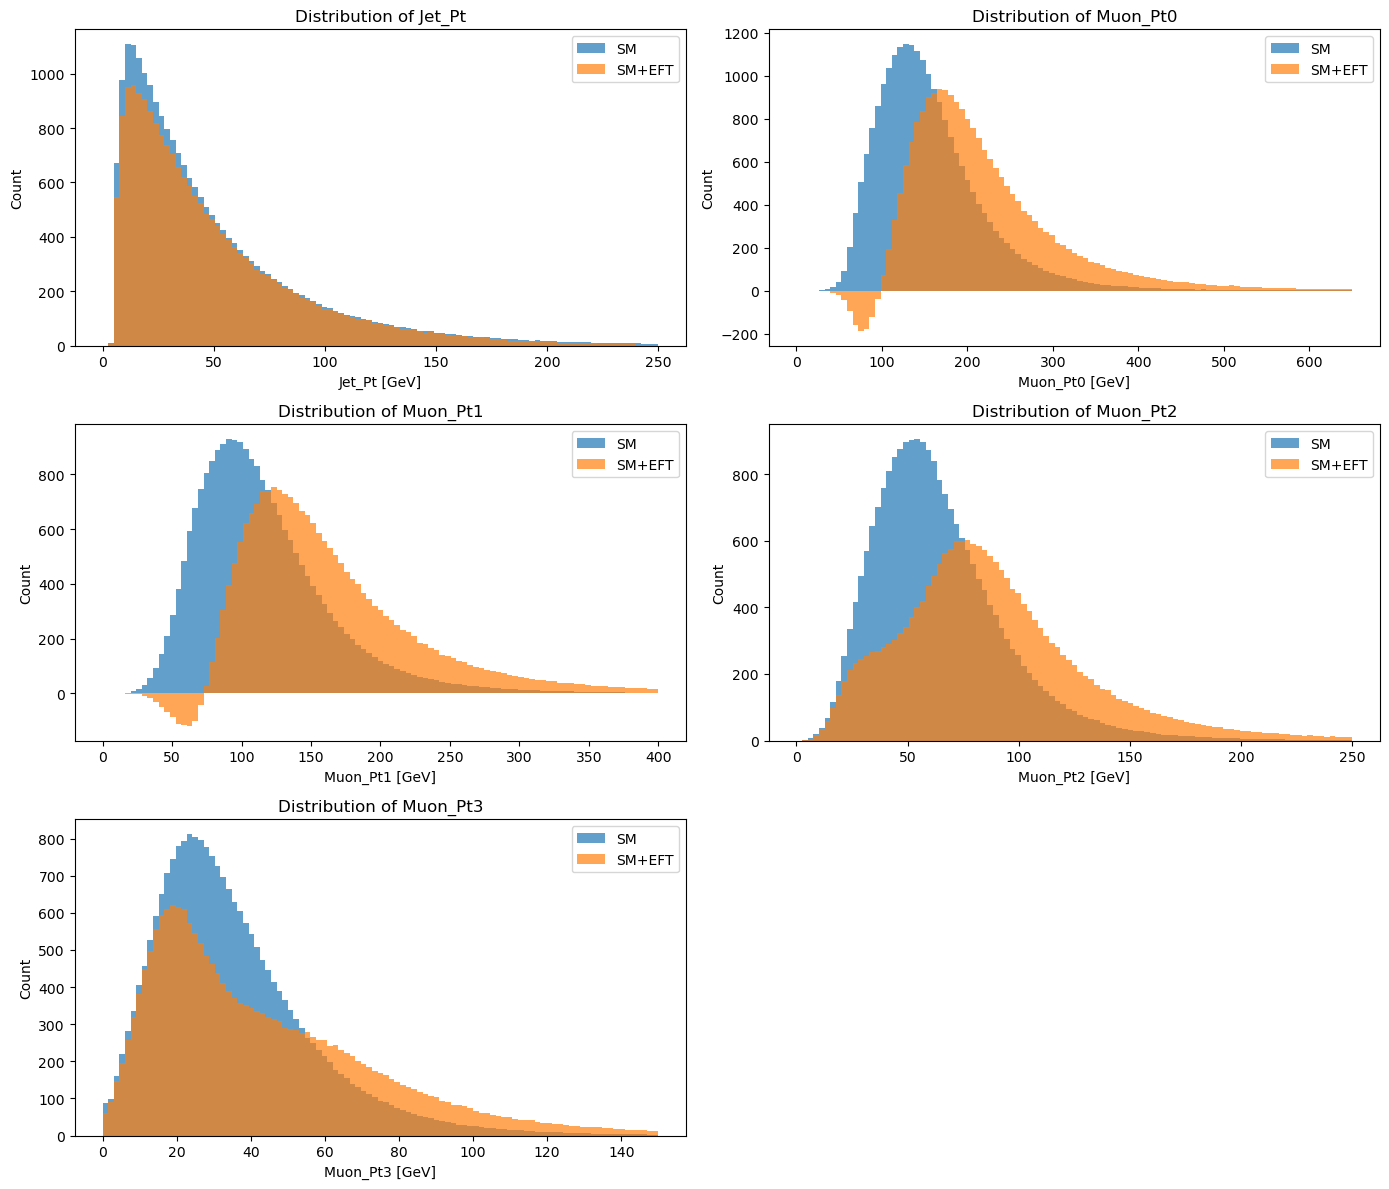

In [7]:
fig = plt.figure(figsize=(14, 12))
gs = matplotlib.gridspec.GridSpec(3, 2)

features = ['Jet_Pt', 'Muon_Pt0', 'Muon_Pt1', 'Muon_Pt2', 'Muon_Pt3']
bins_dict = {
    'Jet_Pt': np.linspace(0, 250, 100),
    'Muon_Pt0': np.linspace(0, 650, 100),
    'Muon_Pt1': np.linspace(0, 400, 100),
    'Muon_Pt2': np.linspace(0, 250, 100),
    'Muon_Pt3': np.linspace(0, 150, 100),
}

for idx, feature in enumerate(features):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    bins = bins_dict[feature]
    
    ax.hist(source_array[:, keys.index(feature)], weights=source_array[:,-1], bins=bins,
            color='tab:blue', alpha=0.7, label=r"SM")
    ax.hist(target_array[:, keys.index(feature)], weights=target_array[:,-1], bins=bins,
            color='tab:orange', alpha=0.7, label=r"SM+EFT")
    ax.set_xlabel(f"{feature} [GeV]")
    ax.set_ylabel("Count")
    ax.legend()
    ax.set_title(f"Distribution of {feature}")

# Hide the empty subplot in the 3x2 grid (position [2, 1])
ax = fig.add_subplot(gs[2, 1])
ax.axis('off')

fig.tight_layout()

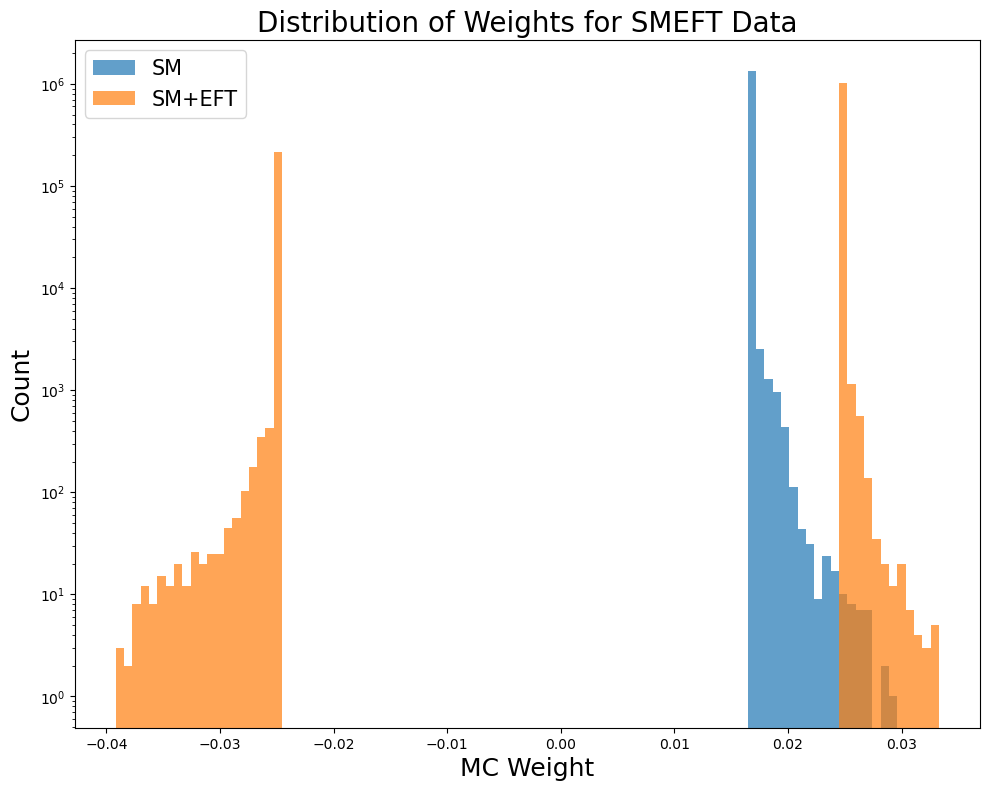

In [8]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

bins = np.linspace(np.min((source_array[:,-1].min(), target_array[:,-1].min())),
                   np.max((source_array[:,-1].max(), target_array[:,-1].max())),
                   100)
ax.hist(source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT");
ax.set_xlabel(r"MC Weight", size=18)
ax.set_ylabel("Count", size=18)
ax.set_yscale("log")
ax.legend(prop={'size': 15})
ax.set_title(r"Distribution of Weights for SMEFT Data", size=20)
fig.tight_layout()

# Now apply more cuts to the data

In [9]:
def get_HH_4vec(array, keys, nMuons=4):
    """
    Reconstruct the Higgs pair 4-vector by summing muon 4-vectors.
    
    Parameters:
    -----------
    array : np.ndarray
        Feature array with shape (n_events, n_features)
    keys : list
        List of feature names corresponding to columns in array
    nMuons : int
        Number of muons to sum (default: 4)
    
    Returns:
    --------
    vector.array
        4-vector with pt, eta, phi, M components
    """
    ZEROS = np.zeros_like(array[:, 0])
    MUON_PT_IX = keys.index('Muon_Pt0')
    MUON_ETA_IX = keys.index('Muon_Eta0')
    MUON_PHI_IX = keys.index('Muon_Phi0')
    
    # Initialize empty 4-vector
    HH_4vec = vector.array({"pt": ZEROS, "eta": ZEROS, "phi": ZEROS, "M": ZEROS})
    
    # Sum muon 4-vectors (muon mass = 0.10566 GeV, fixed in this dataset)
    for i in range(nMuons):
        HH_4vec += vector.array({
            "pt": array[:, MUON_PT_IX + i],
            "eta": array[:, MUON_ETA_IX + i],
            "phi": array[:, MUON_PHI_IX + i],
            "M": np.ones_like(array[:, MUON_PT_IX + i]) * 0.10566001
        })
    
    return HH_4vec

In [10]:
WEIGHT_NAME = "mcEventWeight"

data_arrays = []
for path in [source_path, target_path]:
    print("Starting processing for:", path)
    tree = uproot.open(path+".root")["Events"]
    keys = sorted(tree.keys())
    keys.remove(WEIGHT_NAME)
    
    arr = tree.arrays(library='np')
    arr = np.concatenate([arr[key] for key in keys], axis=1)
    arr = np.concatenate([arr, tree.arrays(WEIGHT_NAME, library='np')[WEIGHT_NAME]], axis=1)
    print(f"Initial shape: {arr.shape}")
    
    # Basic kinematic cuts
    masks = [
        arr[:, keys.index("Njets")] >= 1,
        arr[:, keys.index("Jet_Pt")] > 0,
        arr[:, keys.index("Jet_Mass")] > 0,
        arr[:, keys.index("Muon_Pt0")] > 0,
        arr[:, keys.index("Muon_Pt1")] > 0,
        arr[:, keys.index("Muon_Pt2")] > 0,
        arr[:, keys.index("Muon_Pt3")] > 0,
        abs(arr[:, keys.index("Jet_Eta")]) < 5,
        abs(arr[:, keys.index("Muon_Eta0")]) < 5,
        abs(arr[:, keys.index("Muon_Eta1")]) < 5,
        abs(arr[:, keys.index("Muon_Eta2")]) < 5,
        abs(arr[:, keys.index("Muon_Eta3")]) < 5,
    ]
    
    CUTS = np.ones(arr.shape[0], dtype=bool)
    for mask in masks:
        CUTS &= mask
    arr = arr[CUTS]
    print(f"After kinematic cuts: {arr.shape}, retained {CUTS.sum()/len(CUTS)*100:.1f}%\n")
    
    # Remove fixed/unused features
    names_to_remove = ["Njets", "Muon_Mass0", "Muon_Mass1", "Muon_Mass2", "Muon_Mass3"]
    for name in names_to_remove:
        arr = np.delete(arr, keys.index(name), axis=1)
        keys.remove(name)
    
    data_arrays.append(arr)

print("Applying percentile-based cuts to ensure support overlap...")

# Apply percentile-based cuts to ensure support overlap
cut_percentile = 99.8
cuts = {
    "Jet_Pt": (0, np.percentile(data_arrays[0][:, keys.index("Jet_Pt")], cut_percentile)),
    "Muon_Pt0": (0, np.percentile(data_arrays[0][:, keys.index("Muon_Pt0")], cut_percentile)),
    "Muon_Pt1": (0, np.percentile(data_arrays[0][:, keys.index("Muon_Pt1")], cut_percentile)),
    "Muon_Pt2": (0, np.percentile(data_arrays[0][:, keys.index("Muon_Pt2")], cut_percentile)),
    "Muon_Pt3": (0, np.percentile(data_arrays[0][:, keys.index("Muon_Pt3")], cut_percentile)),
}

for i, arr in enumerate(data_arrays):
    mask = np.ones(arr.shape[0], dtype=bool)
    for name, (cut_low, cut_high) in cuts.items():
        mask &= (arr[:, keys.index(name)] >= cut_low) & (arr[:, keys.index(name)] <= cut_high)
    data_arrays[i] = arr[mask]
    print(f"After percentile cuts: {data_arrays[i].shape}, retained {mask.sum()/len(mask)*100:.1f}%")

source_array, target_array = data_arrays


Starting processing for: ./data/SMEFT_SM_combined_tuple
Initial shape: (1350000, 22)
After kinematic cuts: (1327165, 22), retained 98.3%

Starting processing for: ./data/SMEFT_EFT_combined_tuple
Initial shape: (1260000, 22)
After kinematic cuts: (1239575, 22), retained 98.4%

Applying percentile-based cuts to ensure support overlap...
After percentile cuts: (1317743, 17), retained 99.3%
After percentile cuts: (1194415, 17), retained 96.4%


In [15]:
s_shape = source_array.shape
t_shape = target_array.shape

print(f"Source: {s_shape[0]:,} events x {s_shape[1]:,} columns")
print(f"Target: {t_shape[0]:,} events x {t_shape[1]:,} columns")
print()

print("Feature columns (column index -> name):")
for i, name in enumerate(keys):
    print(f"{i:2d} -> {name}")
weight_idx = s_shape[1] - 1
print(f"{weight_idx:2d} -> {WEIGHT_NAME}  (appended as last column)")

if s_shape[1] != len(keys) + 1 or t_shape[1] != len(keys) + 1:
    print("\nWarning: number of columns does not match len(keys)+1")

Source: 1,317,743 events x 17 columns
Target: 1,194,415 events x 17 columns

Feature columns (column index -> name):
 0 -> Jet_Eta
 1 -> Jet_Mass
 2 -> Jet_Phi
 3 -> Jet_Pt
 4 -> Muon_Eta0
 5 -> Muon_Eta1
 6 -> Muon_Eta2
 7 -> Muon_Eta3
 8 -> Muon_Phi0
 9 -> Muon_Phi1
10 -> Muon_Phi2
11 -> Muon_Phi3
12 -> Muon_Pt0
13 -> Muon_Pt1
14 -> Muon_Pt2
15 -> Muon_Pt3
16 -> mcEventWeight  (appended as last column)


### Get the Higgs 4 vectors

In [11]:
source_HH_4vec = get_HH_4vec(source_array, keys, nMuons=4)
target_HH_4vec = get_HH_4vec(target_array, keys, nMuons=4)

## Look at the same plots now after the cuts

Text(0.5, 1.0, 'Distribution of $m_{HH}$ for Data')

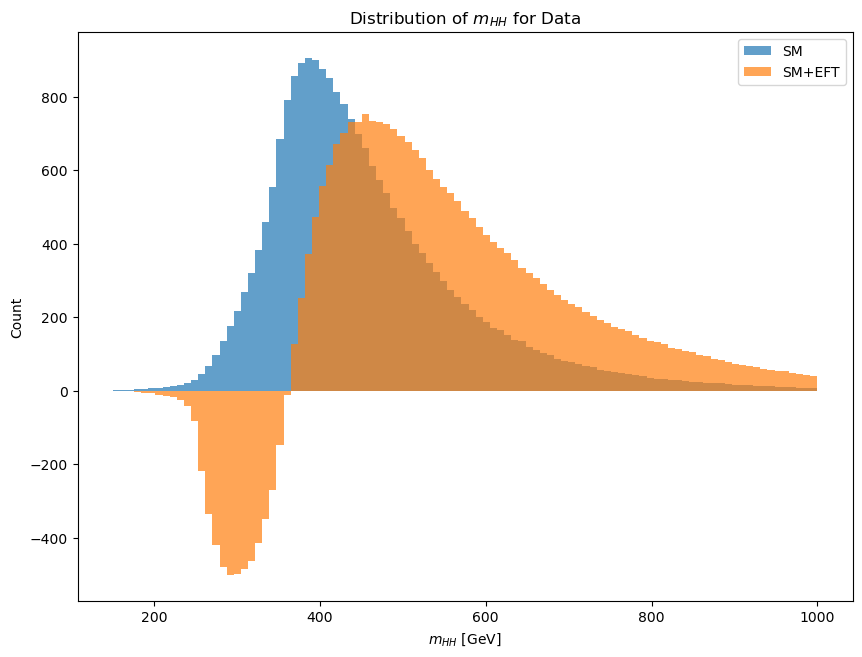

In [12]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = target_array[:,-1] < 0
pos_mask = ~neg_mask

bins = np.linspace(150, 1000, 100)
ax.hist(source_HH_4vec.M, weights=source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_HH_4vec.M, weights=target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT");
ax.set_xlabel(r"$m_{HH}$ [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of $m_{HH}$ for Data")

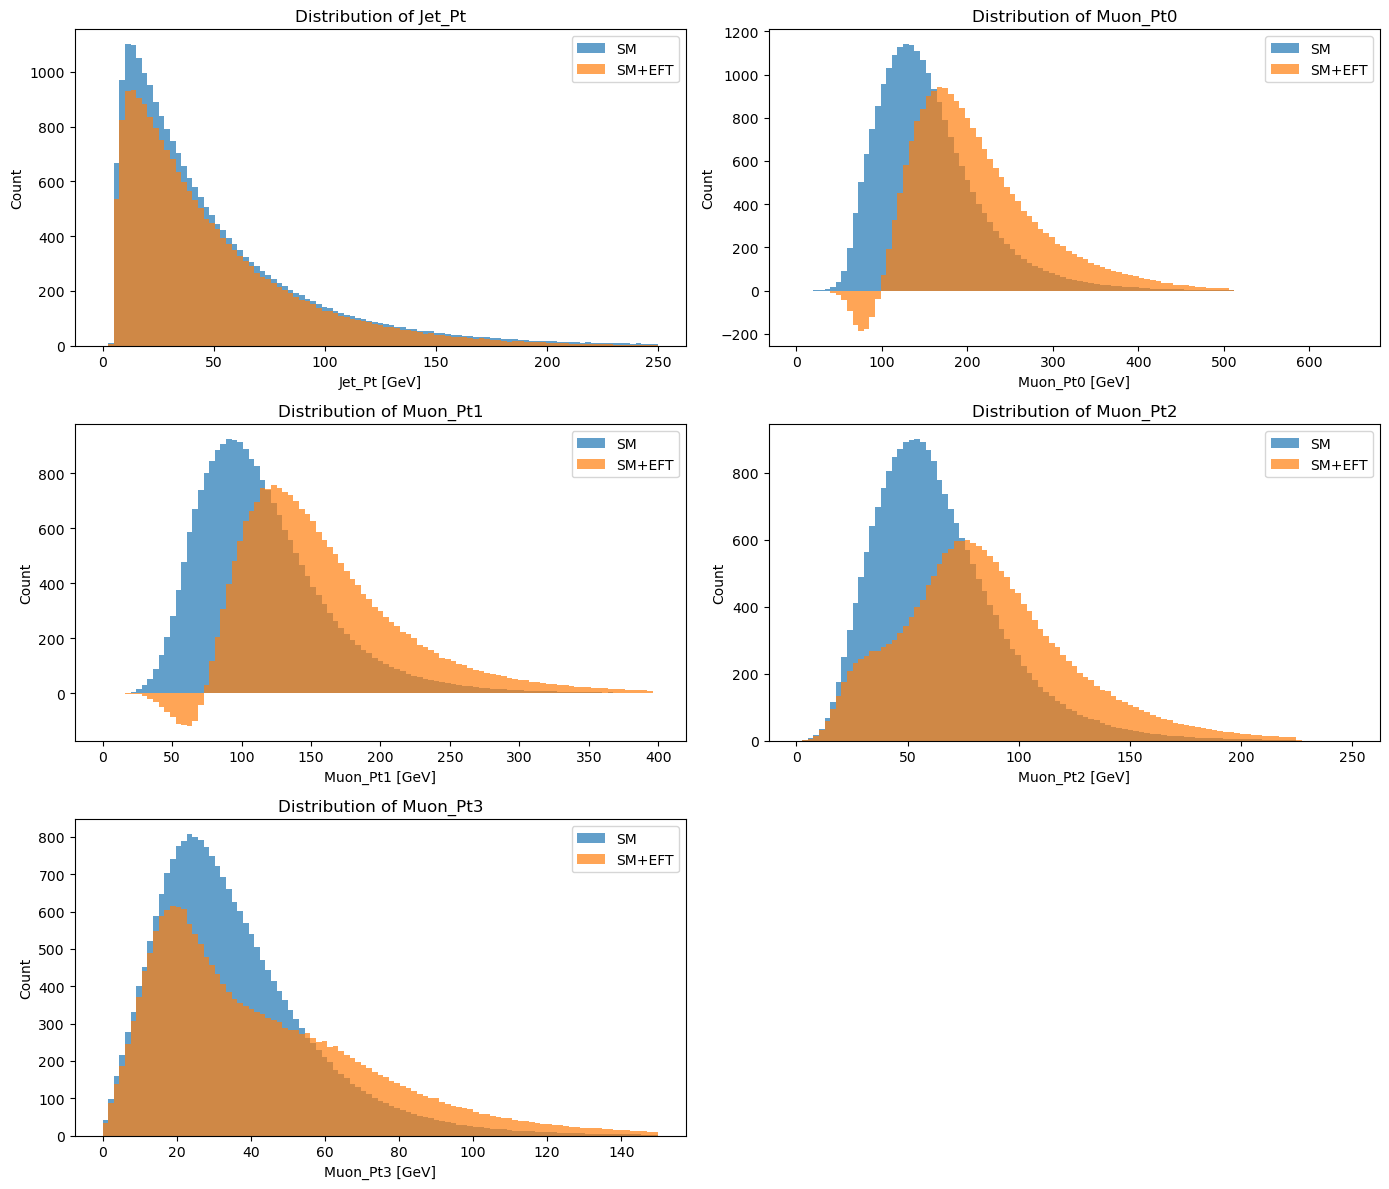

In [13]:
fig = plt.figure(figsize=(14, 12))
gs = matplotlib.gridspec.GridSpec(3, 2)

features = ['Jet_Pt', 'Muon_Pt0', 'Muon_Pt1', 'Muon_Pt2', 'Muon_Pt3']
bins_dict = {
    'Jet_Pt': np.linspace(0, 250, 100),
    'Muon_Pt0': np.linspace(0, 650, 100),
    'Muon_Pt1': np.linspace(0, 400, 100),
    'Muon_Pt2': np.linspace(0, 250, 100),
    'Muon_Pt3': np.linspace(0, 150, 100),
}

for idx, feature in enumerate(features):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    bins = bins_dict[feature]
    
    ax.hist(source_array[:, keys.index(feature)], weights=source_array[:,-1], bins=bins,
            color='tab:blue', alpha=0.7, label=r"SM")
    ax.hist(target_array[:, keys.index(feature)], weights=target_array[:,-1], bins=bins,
            color='tab:orange', alpha=0.7, label=r"SM+EFT")
    ax.set_xlabel(f"{feature} [GeV]")
    ax.set_ylabel("Count")
    ax.legend()
    ax.set_title(f"Distribution of {feature}")

# Hide the empty subplot in the 3x2 grid (position [2, 1])
ax = fig.add_subplot(gs[2, 1])
ax.axis('off')

fig.tight_layout()

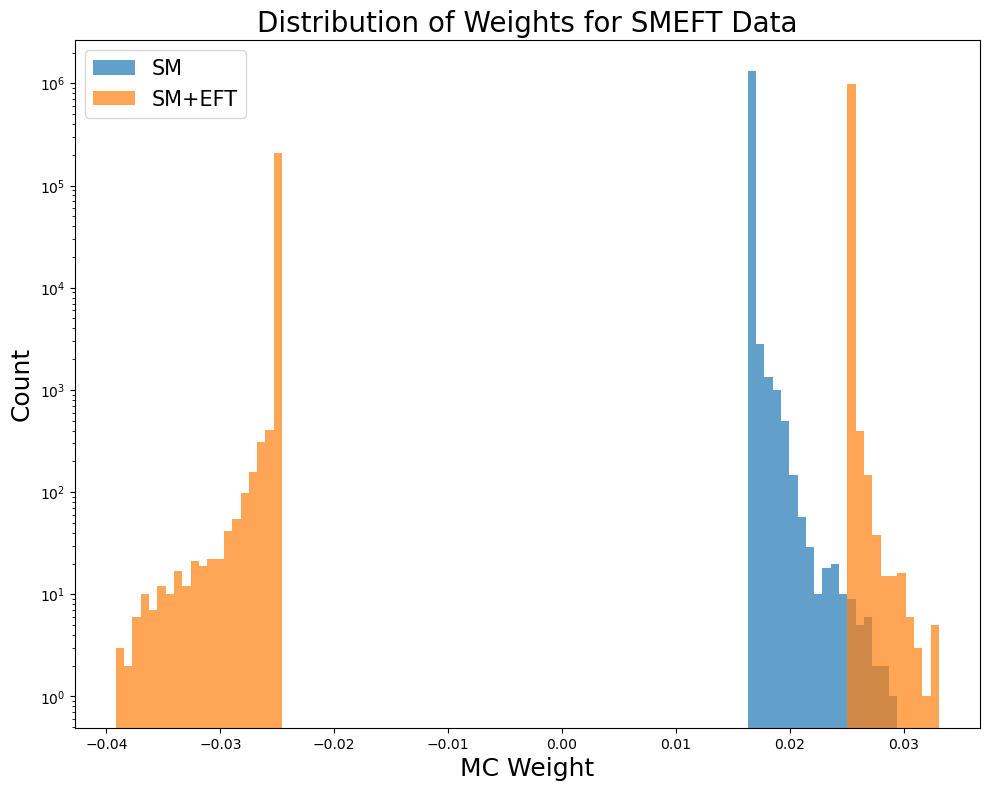

In [14]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

bins = np.linspace(np.min((source_array[:,-1].min(), target_array[:,-1].min())),
                   np.max((source_array[:,-1].max(), target_array[:,-1].max())),
                   100)
ax.hist(source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT");
ax.set_xlabel(r"MC Weight", size=18)
ax.set_ylabel("Count", size=18)
ax.set_yscale("log")
ax.legend(prop={'size': 15})
ax.set_title(r"Distribution of Weights for SMEFT Data", size=20)
fig.tight_layout()

# Split into training/validation/testing datasets

In [16]:
# sample size and train/val/test splits
N = min([int(source_array.shape[0]), int(target_array.shape[0])])
training_cutoff = int(0.65 * N) # 65%
validation_cutoff = int(0.15 * N) # 15%
testing_cutoff = int(0.2 * N) # 20%
training_cutoff, validation_cutoff, testing_cutoff

(776369, 179162, 238883)

In [ ]:
if SAVE_DATA is True:
    np.random.shuffle(source_array)
    np.save(osp.splitext(source_path)[0] + "_train.npy", source_array[:training_cutoff])
    np.save(osp.splitext(source_path)[0] + "_val.npy", source_array[training_cutoff:training_cutoff+validation_cutoff])
    np.save(osp.splitext(source_path)[0] + "_test.npy", source_array[training_cutoff+validation_cutoff:training_cutoff+validation_cutoff+testing_cutoff])

In [ ]:
if SAVE_DATA is True:
    np.random.shuffle(target_array)
    np.save(osp.splitext(target_path)[0] + "_train.npy", target_array[:training_cutoff])
    np.save(osp.splitext(target_path)[0] + "_val.npy", target_array[training_cutoff:training_cutoff+validation_cutoff])
    np.save(osp.splitext(target_path)[0] + "_test.npy", target_array[training_cutoff+validation_cutoff:training_cutoff+validation_cutoff+testing_cutoff])